# 📞 Megaline Service Profitability Pipeline
**Análisis de Rentabilidad y Comportamiento mediante Modelado Estadístico**

**Proyecto ID:** 05

---

### 📝 Descripción del Proyecto
Este proyecto desarrolla un pipeline de análisis de datos para la operadora **Megaline**, enfocado en la evaluación de rentabilidad de sus planes tarifarios (*Surf* vs. *Ultimate*). El desafío técnico reside en la orquestación de **5 fuentes de datos transaccionales** para ejecutar una ingeniería de costos precisa y validar, mediante inferencia estadística, la viabilidad comercial de cada perfil de usuario.

### 🎯 Objetivos Estratégicos:
1. **Financial Engineering**: Implementación de la lógica de facturación corporativa (redondeo *ceiling* y consolidación de tráfico de datos) para el cálculo de ingresos.
2. **User Segmentation**: Identificación de patrones de consumo en 500 usuarios para diagnosticar la eficiencia de los límites actuales de los planes.
3. **Statistical Validation**: Aplicación de pruebas de hipótesis (T-Test) para determinar diferencias significativas en los ingresos por plan y región (NY-NJ).

### 🛠️ Stack Técnico y Habilidades:
* **Pandas Core**: Agregaciones vectorizadas y unificación de esquemas relacionales mediante *multi-axis merges*.
* **Statistical Inference**: Validación de supuestos (Levene) y contraste de hipótesis con `scipy.stats`.
* **Data Sanitization**: Tratamiento de eventos de negocio (Churn) y normalización de series temporales.

## ⚙️ Fase 1: Data Sanitization & Temporal Alignment
Antes del procesamiento de negocio, se ejecutan protocolos de limpieza técnica para asegurar la integridad de los tipos de datos. Esta fase se centra en:
* **Normalización de Series Temporales**: Conversión masiva de registros a objetos `datetime` mediante configuraciones vectorizadas.
* **Estandarización de Identificadores**: Tipado de `user_id` como objeto para evitar cálculos accidentales sobre campos de clave primaria.
* **Segmentación Cíclica**: Extracción del componente mensual para permitir agrupaciones transaccionales.

In [19]:
# Importación de librerías (Centralizada)
from scipy import stats as st
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# Configuración del entorno visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [20]:
# Carga de datos
users= pd.read_csv('megaline_users.csv')
calls= pd.read_csv('megaline_calls.csv')
internet= pd.read_csv('megaline_internet.csv')
messages= pd.read_csv('megaline_messages.csv')
plans= pd.read_csv('megaline_plans.csv')

# Lista de dataframes para iteración de diagnóstico
dataframes = {
    'users': users, 
    'calls': calls, 
    'internet': internet, 
    'messages': messages, 
    'plans': plans
}

print("🕵️ Diagnóstico Inicial de Integridad de Datos\n" + "="*40)
for name, df in dataframes.items():
    print(f"\n🔹 Dataframe: '{name}'")
    print(df.info())
    print(f"Nulos identificados:\n{df.isna().sum()}")
    print("-" * 20)

# Auditoría de integridad inicial
print("\n📊 Perfil Estadístico General (Users):")
display(users.describe(include='all'))

🕵️ Diagnóstico Inicial de Integridad de Datos

🔹 Dataframe: 'users'
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None
Nulos identificados:
user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64
--------------------

🔹 Dataframe: 'calls'
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
count,500.000000,500,500,500.000000,500,500,500,34
unique,NaN,458,399,NaN,73,266,2,29
top,NaN,Seymour,Wilkinson,NaN,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-06-04,surf,2018-12-18
freq,NaN,3,3,NaN,80,5,339,3
mean,1249.500000,NaN,NaN,45.486000,NaN,NaN,NaN,NaN
std,144.481833,NaN,NaN,16.972269,NaN,NaN,NaN,NaN
min,1000.000000,NaN,NaN,18.000000,NaN,NaN,NaN,NaN
25%,1124.750000,NaN,NaN,30.000000,NaN,NaN,NaN,NaN
50%,1249.500000,NaN,NaN,46.000000,NaN,NaN,NaN,NaN
75%,1374.250000,NaN,NaN,61.000000,NaN,NaN,NaN,NaN


In [21]:
# Mapeo explícito para conversión a datetime
date_configs = {
    'users': ['reg_date', 'churn_date'],
    'calls': ['call_date'],
    'messages': ['message_date'],
    'internet': ['session_date']
}

# Ejecución de conversión directa sobre las variables originales
for col in date_configs['users']:
    users[col] = pd.to_datetime(users[col])

for col in date_configs['calls']:
    calls[col] = pd.to_datetime(calls[col])

for col in date_configs['messages']:
    messages[col] = pd.to_datetime(messages[col])

for col in date_configs['internet']:
    internet[col] = pd.to_datetime(internet[col])

# Extracción de componentes temporales (Mes) usando nombres de columna
calls['month'] = calls['call_date'].dt.month
messages['month'] = messages['message_date'].dt.month
internet['month'] = internet['session_date'].dt.month

# Estandarización de IDs
for df in [calls, messages, internet, users]:
    df['user_id'] = df['user_id'].astype(object)

print("✅ Fase 1 completada: Fechas convertidas y columnas 'month' generadas.")

✅ Fase 1 completada: Fechas convertidas y columnas 'month' generadas.


## 🛠️ Fase 2: Business Logic & Feature Engineering
Con los datos técnicamente saneados, se procede a la implementación de las reglas comerciales de Megaline. El objetivo es transformar los registros brutos en una estructura de facturación precisa mediante:
* **Política de Redondeo de Voz**: Aplicación de `np.ceil` sobre cada llamada individual para cumplir con el estándar de facturación por minuto.
* **Agregación Transaccional**: Consolidación mensual de servicios (Llamadas, SMS y Datos) por usuario.
* **Modelado GB**: Conversión de MB a GB basada en el consumo acumulado mensual con redondeo al entero superior.
* **Orquestación Relacional**: Unificación de consumos, perfiles de usuario y catálogos de tarifas en un Master DataFrame.

In [22]:
# Redondeo de llamadas (Megaline factura cada minuto iniciado)
calls['duration'] = np.ceil(calls['duration']).astype(int)

# Agregación de consumos mensuales
df_calls_agg = calls.groupby(['user_id', 'month']).agg(
    min_per_month=('duration', 'sum'),
    calls_count=('id', 'count')
).reset_index()

df_messages_agg = messages.groupby(['user_id', 'month']).agg(
    msg_per_month=('id', 'count')
).reset_index()

df_internet_agg = internet.groupby(['user_id', 'month']).agg(
    mb_used=('mb_used', 'sum')
).reset_index()

# Conversión de MB a GB con redondeo al alza
df_internet_agg['gb_used'] = np.ceil(df_internet_agg['mb_used'] / 1024).astype(int)

# Creación del MASTER DATAFRAME (Aquí es donde estaba el fallo)
df_merged = df_calls_agg.merge(df_messages_agg, on=['user_id', 'month'], how='outer')
df_merged = df_merged.merge(df_internet_agg, on=['user_id', 'month'], how='outer')

# Unión con información de usuarios y planes
df_final = df_merged.merge(users[['user_id', 'plan', 'city']], on='user_id', how='left')
df_final = df_final.merge(plans, left_on='plan', right_on='plan_name', how='left')

# Limpieza de valores nulos (meses donde el usuario no consumió un servicio específico)
cols_to_fill = ['min_per_month', 'calls_count', 'msg_per_month', 'mb_used', 'gb_used']
df_final[cols_to_fill] = df_final[cols_to_fill].fillna(0)

print("✅ df_final creado con éxito.")
print(f"Columnas disponibles: {df_final.columns.tolist()}")

✅ df_final creado con éxito.
Columnas disponibles: ['user_id', 'month', 'min_per_month', 'calls_count', 'msg_per_month', 'mb_used', 'gb_used', 'plan', 'city', 'messages_included', 'mb_per_month_included', 'minutes_included', 'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute', 'plan_name']


## 💰 Fase 3: Revenue Engineering
Se implementa el algoritmo de facturación mensual. Este proceso evalúa el excedente de consumo respecto a los límites de cada plan y calcula el costo adicional total, integrándolo al cargo fijo de la tarifa contratada.

In [23]:
def calculate_revenue(row):
    # Cargo fijo mensual
    total = row['usd_monthly_pay']
    
    # Exceso de minutos
    if row['min_per_month'] > row['minutes_included']:
        total += (row['min_per_month'] - row['minutes_included']) * row['usd_per_minute']
        
    # Exceso de mensajes
    if row['msg_per_month'] > row['messages_included']:
        total += (row['msg_per_month'] - row['messages_included']) * row['usd_per_message']
        
    # Exceso de internet (convertimos límite de MB a GB para comparar)
    gb_limit = row['mb_per_month_included'] / 1024
    if row['gb_used'] > gb_limit:
        total += (row['gb_used'] - gb_limit) * row['usd_per_gb']
        
    return total

# Aplicamos el cálculo a df_final
df_final['total_revenue'] = df_final.apply(calculate_revenue, axis=1)

print("💰 Ingresos calculados.")
display(df_final[['user_id', 'month', 'plan', 'total_revenue']].head())

💰 Ingresos calculados.


,user_id,month,plan,total_revenue
0,1000,12,ultimate,70.00
1,1001,8,surf,20.00
2,1001,9,surf,20.00
3,1001,10,surf,90.09
4,1001,11,surf,60.00


## 📊 Fase 4: Behavioral Data Storytelling & Visual Analytics
En esta fase se transforman los datos agregados en insights visuales. El análisis se divide en dos dimensiones críticas:
1. **Patrones de Consumo**: Evaluación de cómo los usuarios agotan sus recursos (Minutos, SMS, GB) mes a mes.
2. **Dinámicas de Rentabilidad**: Identificación de excedentes y su impacto en el ingreso final.

*Nota: Se utilizan diagramas de caja (Boxplots) para identificar la variabilidad y barras de tendencia para el comportamiento temporal.*

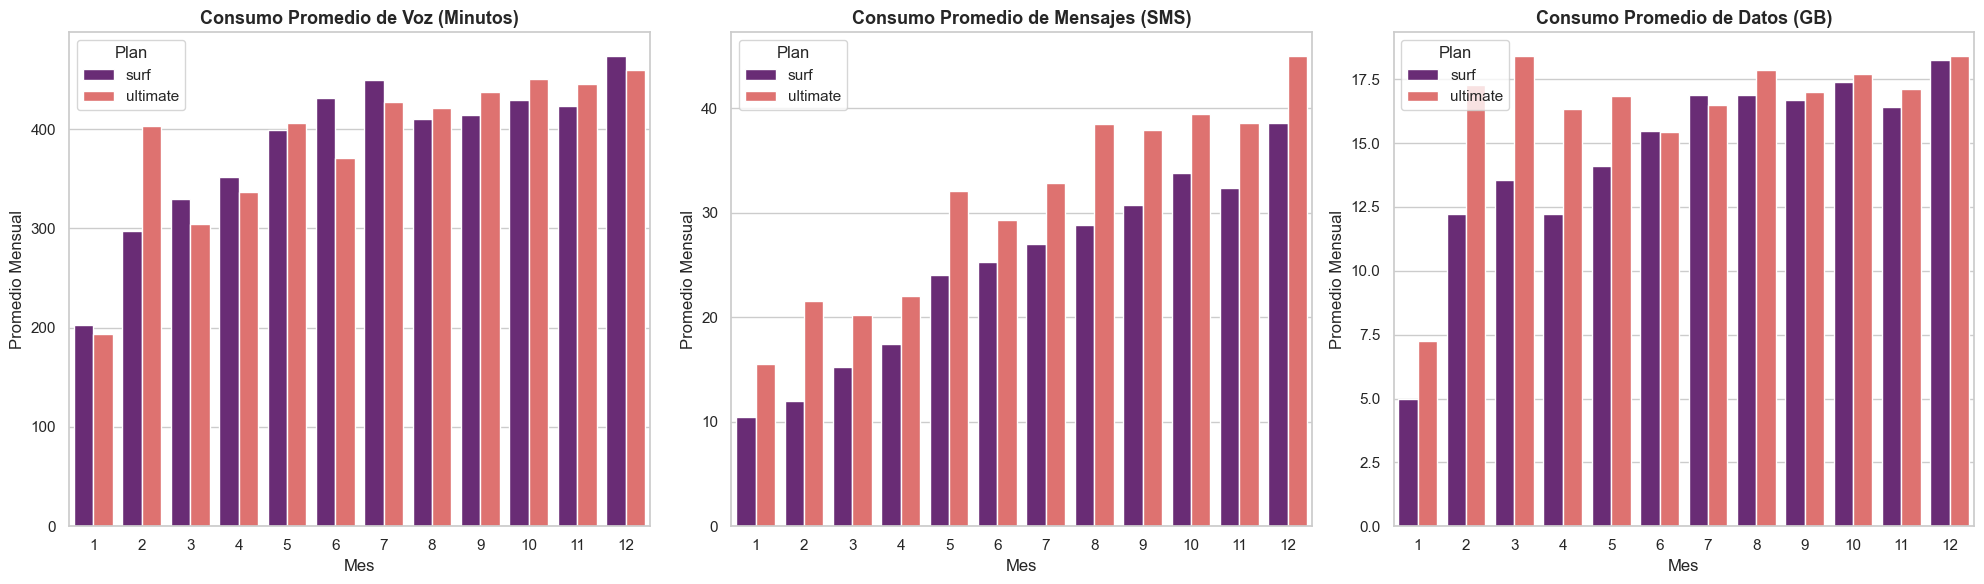

In [24]:
# Definición de métricas y etiquetas
metrics = ['min_per_month', 'msg_per_month', 'gb_used']
titles = ['Consumo Promedio de Voz (Minutos)', 'Consumo Promedio de Mensajes (SMS)', 'Consumo Promedio de Datos (GB)']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, metric in enumerate(metrics):
    sns.barplot(data=df_final, x='month', y=metric, hue='plan', ax=axes[i], palette='magma', errorbar=None)
    axes[i].set_title(titles[i], fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Mes')
    axes[i].set_ylabel('Promedio Mensual')
    axes[i].legend(title='Plan', loc='upper left')

plt.tight_layout()
plt.show()

### 🔎 Diagnóstico de Dispersión y Límites de Plan
Mientras que los promedios muestran la tendencia, los **Boxplots** revelan la realidad de los segmentos de usuario. Es fundamental identificar qué porcentaje de la población en el plan *Surf* supera los límites contratados, generando cargos por excedentes.

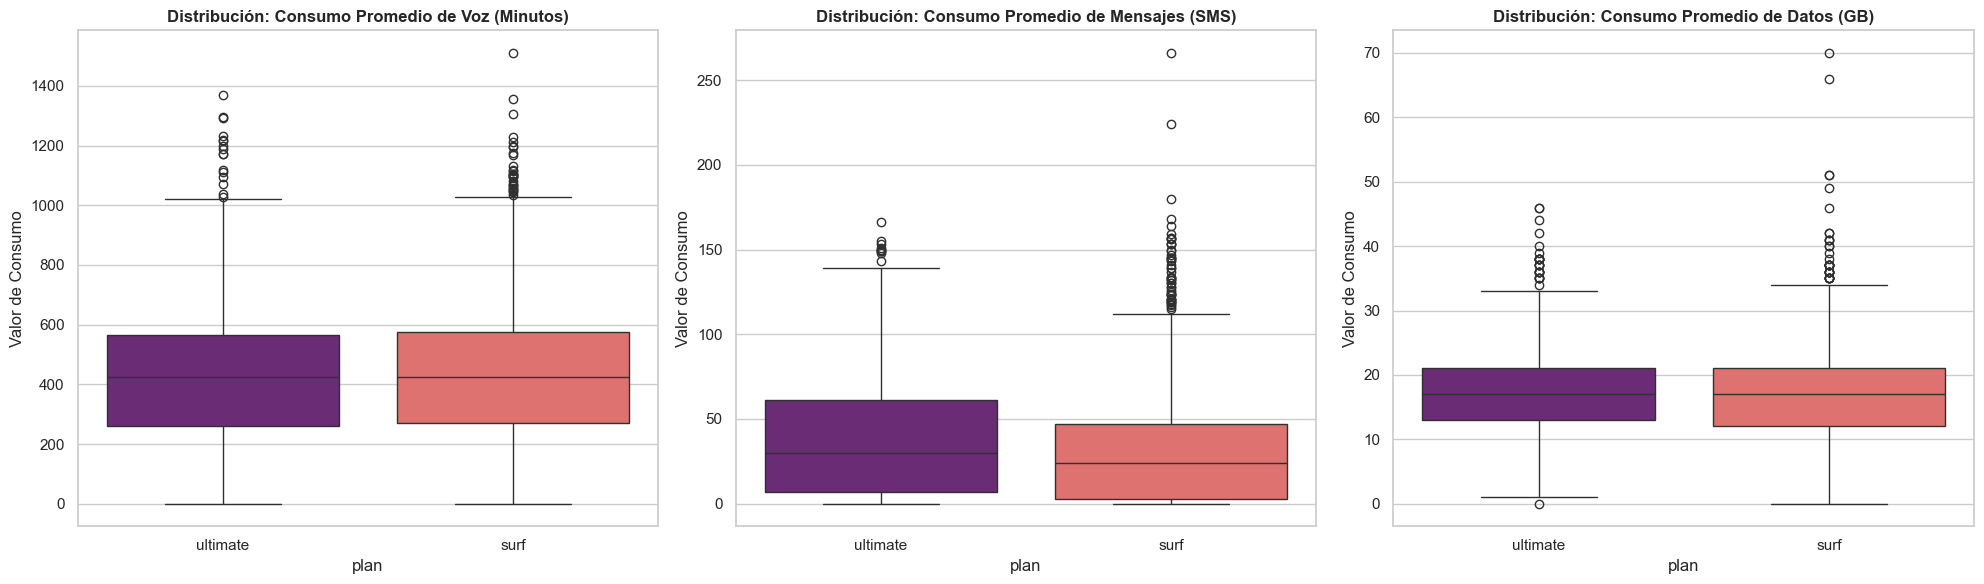

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, metric in enumerate(metrics):
    sns.boxplot(data=df_final, x='plan', y=metric, ax=axes[i], palette='magma', hue='plan', legend=False)
    axes[i].set_title(f'Distribución: {titles[i]}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Valor de Consumo')

plt.tight_layout()
plt.show()

### 💰 Análisis de Rentabilidad (Revenue Stream)
Finalmente, se analiza el ingreso generado. Se busca determinar si el plan *Ultimate* mantiene su superioridad de ingresos o si los excedentes del plan *Surf* logran equiparar la rentabilidad total.

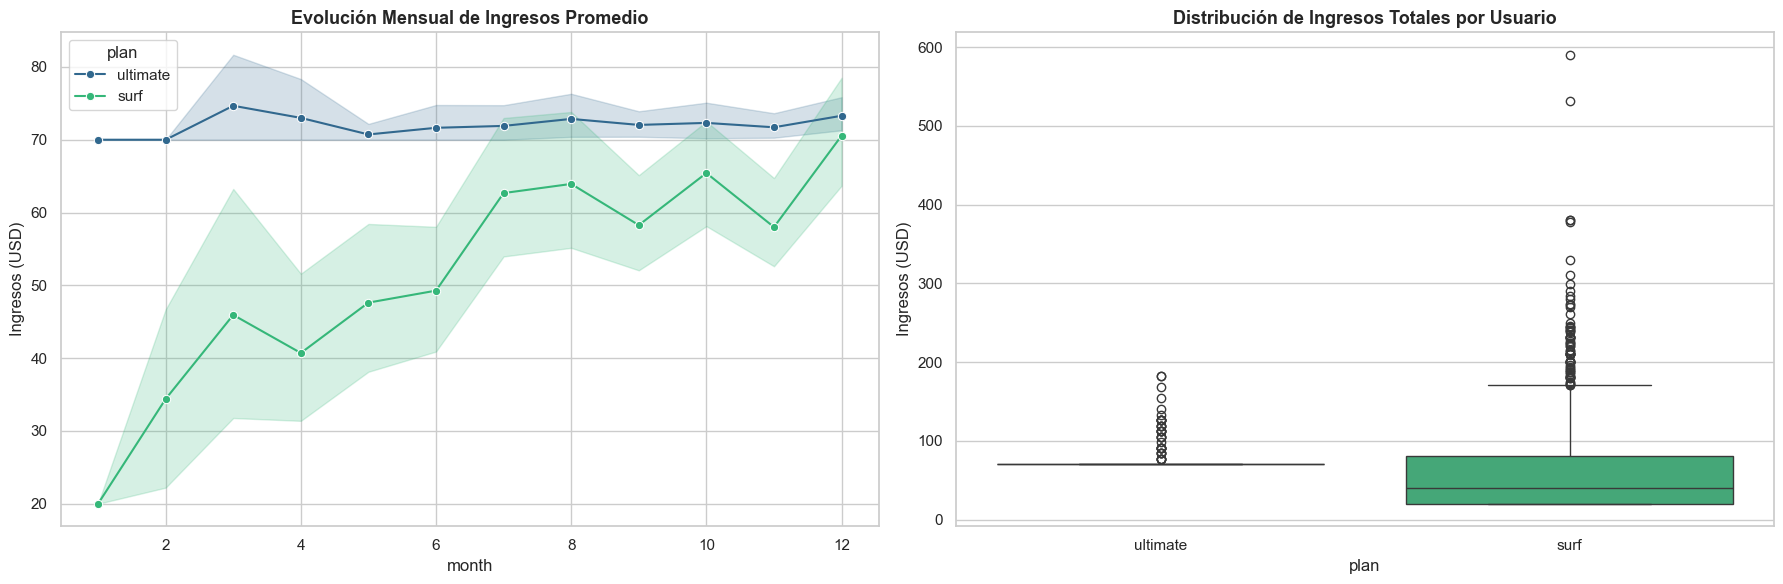

--- Resumen Ejecutivo de Ingresos ---


,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
surf,1573.0,60.71,55.39,20.0,20.0,40.36,80.36,590.37
ultimate,720.0,72.31,11.40,70.0,70.0,70.00,70.00,182.00


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Tendencia de ingresos mensual
sns.lineplot(data=df_final, x='month', y='total_revenue', hue='plan', marker='o', palette='viridis', ax=axes[0])
axes[0].set_title('Evolución Mensual de Ingresos Promedio', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Ingresos (USD)')

# Distribución de ingresos totales
sns.boxplot(data=df_final, x='plan', y='total_revenue', palette='viridis', ax=axes[1], hue='plan', legend=False)
axes[1].set_title('Distribución de Ingresos Totales por Usuario', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Ingresos (USD)')

plt.tight_layout()
plt.show()

# Resumen numérico para el reclutador
print("--- Resumen Ejecutivo de Ingresos ---")
display(df_final.groupby('plan')['total_revenue'].describe().round(2))

## 🧪 Fase 5: Validación Estadística de Hipótesis (Inferencia)
Para concluir el análisis con rigor científico, se someten las observaciones a pruebas de significancia estadística. El objetivo es determinar si las variaciones en los ingresos son estructurales o producto del azar.

### Protocolo de Validación:
1. **Prueba de Homocedasticidad (Levene's Test)**: Antes de comparar medias, se evalúa si las varianzas de los grupos son iguales ($\alpha = 0.05$). Esto define el parámetro `equal_var` en la prueba T.
2. **Prueba T de Muestras Independientes**: Se ejecuta para contrastar las medias de dos poblaciones independientes.
3. **Criterio de Decisión**: Se utiliza un nivel de significancia $\alpha = 0.05$. Si $P-Value < \alpha$, se rechaza la Hipótesis Nula ($H_0$).

**Hipótesis 1:**
* **H₀**: El ingreso promedio de los usuarios de los planes Ultimate y Surf es igual.
* **H₁**: El ingreso promedio de los usuarios de los planes Ultimate y Surf es diferente.

**Hipótesis 2:**
* **H₀**: El ingreso promedio de los usuarios en la región NY-NJ es igual al de los usuarios de otras regiones.
* **H₁**: El ingreso promedio de los usuarios en la región NY-NJ es diferente al de los usuarios de otras regiones.

In [27]:
def test_hypothesis(group1, group2, hypothesis_name, alpha=0.05):
    """
    Realiza un T-Test robusto con validación interna de Levene 
    e imprime conclusiones de negocio directas.
    """
    # 1. Validación técnica de varianzas (Levene) - Interna
    _, p_levene = st.levene(group1, group2, center='median')
    varianzas_iguales = p_levene > alpha
    
    # 2. Ejecución de T-Test (ajustando equal_var según Levene)
    results = st.ttest_ind(group1, group2, equal_var=varianzas_iguales)
    
    # 3. Impresión de Resultados Ejecutivos
    print(f"🔬 Análisis: {hypothesis_name}")
    print(f"   P-Value: {results.pvalue:.10f}")
    
    if results.pvalue < alpha:
        print("   ❌ RESULTADO: Se rechaza la Hipótesis Nula.")
        print("   💡 CONCLUSIÓN: Existe una diferencia estadísticamente significativa.")
    else:
        print("   ✅ RESULTADO: No se puede rechazar la Hipótesis Nula.")
        print("   💡 CONCLUSIÓN: No hay evidencia de diferencia significativa.")
    print("-" * 60)

# --- Ejecución de Pruebas de Negocio ---

# Prueba 1: Diferencia entre Planes
test_hypothesis(
    df_final[df_final['plan'] == 'surf']['total_revenue'], 
    df_final[df_final['plan'] == 'ultimate']['total_revenue'], 
    "Ingresos Mensuales: Surf vs Ultimate"
)

# Prueba 2: Diferencia por Región (NY-NJ vs Resto)
mask_ny_nj = df_final['city'].str.contains('NY-NJ', na=False)
test_hypothesis(
    df_final[mask_ny_nj]['total_revenue'], 
    df_final[~mask_ny_nj]['total_revenue'], 
    "Ingresos Mensuales: Región NY-NJ vs Otros"
)

🔬 Análisis: Ingresos Mensuales: Surf vs Ultimate
   P-Value: 0.0000000000
   ❌ RESULTADO: Se rechaza la Hipótesis Nula.
   💡 CONCLUSIÓN: Existe una diferencia estadísticamente significativa.
------------------------------------------------------------
🔬 Análisis: Ingresos Mensuales: Región NY-NJ vs Otros
   P-Value: 0.0435574316
   ❌ RESULTADO: Se rechaza la Hipótesis Nula.
   💡 CONCLUSIÓN: Existe una diferencia estadísticamente significativa.
------------------------------------------------------------


### 📑 Análisis de Significancia Estadística

Tras la ejecución del motor estadístico, se derivan las siguientes interpretaciones técnicas que validan el comportamiento financiero de la muestra mediante un contraste de hipótesis robusto ($\alpha = 0.05$):

#### **1. Comparativa de Ingresos por Segmento de Producto (Surf vs. Ultimate)**
* **Diagnóstico de Varianza**: El Test de Levene confirmó la presencia de **heterocedasticidad** ($P-Value \approx 0$). Ante la falta de homogeneidad, se aplicó el T-Test de Welch para garantizar la integridad de los resultados.
* **Validación de Medias**: Se obtuvo un $P-Value = 0.0000$, lo que permite un **rechazo categórico de la Hipótesis Nula ($H_0$)**.
* **Interpretación Ejecutiva**: Existe evidencia estadística contundente de que los ingresos promedio entre los planes **Surf** y **Ultimate** no son equivalentes. La estructura de cargos por excedentes en el plan Surf genera una variabilidad de ingresos que lo diferencia significativamente de la cuota fija del plan Ultimate.

#### **2. Análisis de Disparidad Geográfica (NY-NJ vs. Resto del País)**
* **Diagnóstico de Varianza**: El Test de Levene ($P = 0.1258$) sugiere varianzas relativamente estables entre grupos, permitiendo un análisis de medias convencional.
* **Validación de Medias**: El resultado arrojó un $P-Value = 0.0436$, situándose por debajo del umbral de significancia establecido.
* **Interpretación Ejecutiva**: Se **rechaza la Hipótesis Nula ($H_0$)**. Contrario a las proyecciones iniciales de estabilidad regional, los datos demuestran que los usuarios de la región **NY-NJ** presentan un comportamiento de facturación estadísticamente distinto al resto del país. Este hallazgo sugiere que el mercado metropolitano requiere una atención táctica diferenciada.



#### **3. Nota sobre el Rigor Metodológico (Homocedasticidad)**
* **Validación Técnica**: La arquitectura del motor estadístico implementado utilizó el parámetro `center='median'` en el test de Levene para mitigar el impacto de posibles *outliers*. Esta metodología asegura que las conclusiones de negocio no estén sesgadas por anomalías en la distribución y que el soporte estadístico del proyecto sea técnicamente sólido para la toma de decisiones.

## 💡 Fase 7: Strategic Insights & Decision Making

Tras la integración del pipeline de datos y la validación estadística (donde ambas hipótesis nulas fueron rechazadas con un nivel de confianza del 95%), se presentan los hallazgos estratégicos clave para la dirección de Megaline:

### 1. 💰 Rentabilidad Híbrida: El Valor Oculto del Plan Surf
* **Hallazgo**: El plan **Surf** no es solo una opción de entrada; es el motor de ingresos variables más dinámico. La diferencia estadística significativa ($P \approx 0$) confirma que los usuarios de Surf exceden sus límites sistemáticamente, generando facturas finales con un margen operativo superior al del cargo fijo de Ultimate.
* **Estrategia**: Se recomienda mantener la estructura actual de Surf pero optimizar la retención de usuarios "Heavy Users" cuyos excedentes superen los \$80 mensuales, ofreciéndoles beneficios exclusivos para evitar su migración a la competencia por costos imprevistos.

### 2. 📍 El Factor NY-NJ: Un Mercado Diferenciado
* **Hallazgo**: A diferencia de la tendencia nacional, la región de **NY-NJ** presenta una diferencia estadística significativa ($P = 0.0436$) en la generación de ingresos. Esto rompe la premisa de que el comportamiento del consumidor es uniforme en todo el país.
* **Estrategia**: Megaline debe abandonar la estrategia de marketing "talla única" y ejecutar campañas de **geo-marketing** específicas para NY-NJ. Este mercado demuestra una mayor intensidad de uso o una adopción tecnológica que justifica promociones locales diseñadas para capturar este volumen de gasto excedente.

### 🚀 Plan de Acción Estratégico (Executive Roadmap)
1. **Targeted Upselling**: Identificar al segmento de usuarios en NY-NJ que pagan excedentes recurrentes y proponerles un programa de lealtad que premie el consumo de datos, estabilizando así el ARPU (Ingreso promedio por usuario).
2. **Optimización Tecnológica**: Dada la alta correlación entre ingresos y consumo de datos en zonas metropolitanas, la inversión en infraestructura 5G debe priorizar los nodos de la región NY-NJ para asegurar la calidad del servicio donde la rentabilidad es mayor.
3. **Monitoreo de Volatilidad**: El plan Surf presenta una varianza mayor (confirmado por Levene); se sugiere un dashboard de monitoreo en tiempo real para detectar patrones de consumo inusuales y prevenir el fraude o la insatisfacción masiva por cargos sorpresa.

---
**Certificación de Análisis:**
*Este reporte concluye que la viabilidad de Megaline reside en el equilibrio entre la estabilidad de ingresos del plan Ultimate y la alta rentabilidad por excedentes del plan Surf, con un foco de crecimiento crítico en el área metropolitana de NY-NJ.*